In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import pandas as pd

In [2]:
images = []
labels = []

for label in os.listdir("C:\\pythonProjects\\DeepLearning\\VegHealth\\Tomato\\data"):
    folder = os.path.join("C:\\pythonProjects\\DeepLearning\\VegHealth\\Tomato\\data", label)

    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)

        image = Image.open(path).convert("RGB")
        image = image.resize((224, 224))
        images.append(np.array(image))
        labels.append(0 if label == "Tomato__Rotten" else 1)

X = np.array(images)
Y = np.array(labels)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

c:\PythonVenv\machine_Learning\Lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


X shape: (1200, 224, 224, 3)
Y shape: (1200,)


### Exploratory Data Analysis

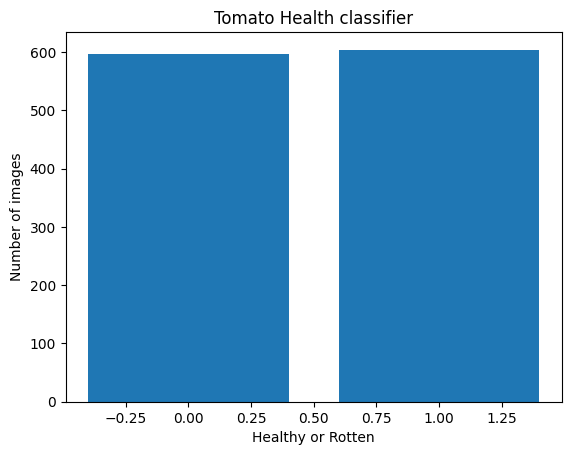

In [3]:
# Note: Plots a bar chart of the count of each class label (healthy vs rotten) in Y
unique, counts = np.unique(Y, return_counts=True)

plt.bar(unique, counts)
plt.xlabel("Healthy or Rotten")
plt.ylabel("Number of images")
plt.title("Tomato Health classifier")
plt.show()

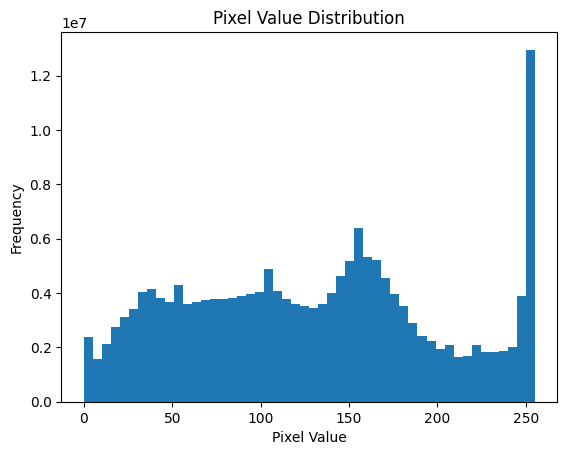

In [4]:
plt.hist(X.flatten(), bins = 50)

plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.title("Pixel Value Distribution")
plt.show()

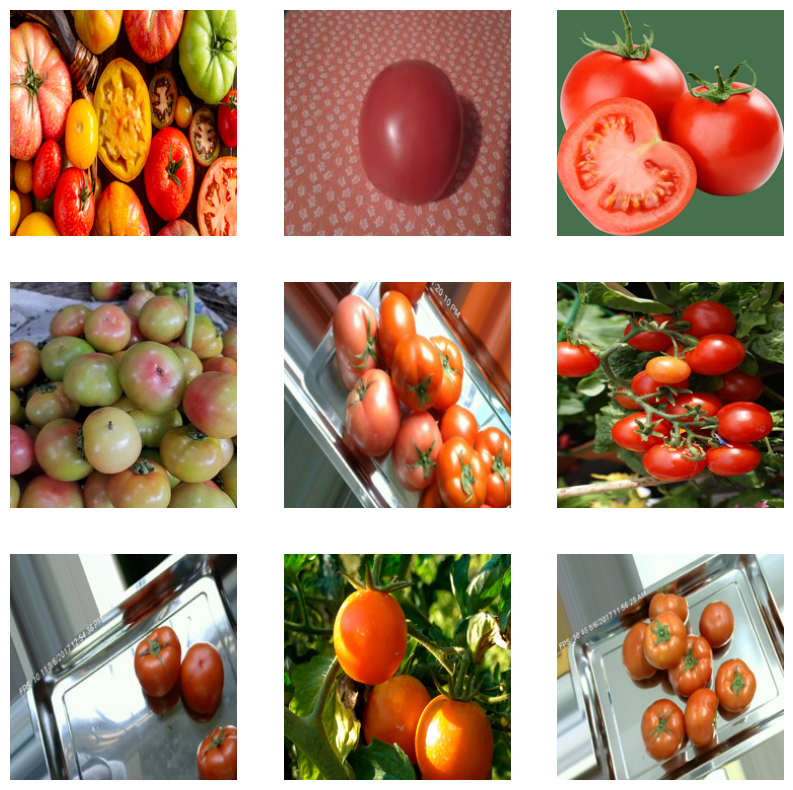

In [5]:
plt.figure(figsize = (10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X[i])
    plt.axis("off")

plt.show()

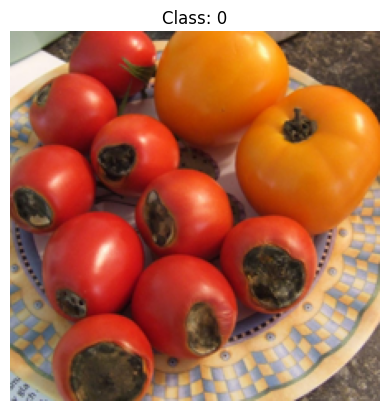

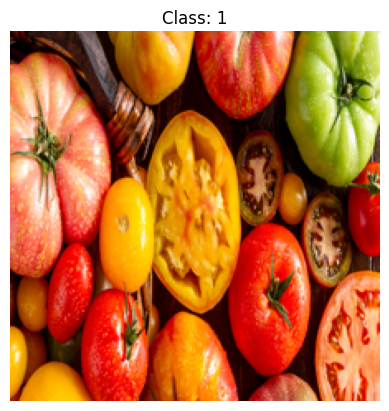

In [6]:
classes = np.unique(Y)

for class_name in classes:
    index = np.where(Y == class_name)[0][0]

    plt.figure()
    plt.imshow(X[index])
    plt.title(f"Class: {class_name}")
    plt.axis("off")
    plt.show()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y, 
    test_size=0.2, 
    random_state=42)

X_test, X_val, Y_test, Y_val = train_test_split(
    X_temp,
    Y_temp, 
    test_size=0.5, 
    random_state=42)

In [11]:
train_gen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 40, 
    shear_range = 0.2, 
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

val_gen = ImageDataGenerator(
    rescale = 1./255
)

train_iterator = train_gen.flow(
    X_train,
    Y_train,
    batch_size = 16,
    shuffle = True
)

val_iterator = val_gen.flow(
    X_val,
    Y_val,
    batch_size = 16,
    shuffle = False
)

LABEL: 1

IMAGE PIXEL ARRAY: 

[[[144 154 145]
  [144 154 145]
  [144 154 145]
  ...
  [161 168 160]
  [161 168 160]
  [161 168 160]]

 [[144 154 145]
  [144 154 145]
  [144 154 145]
  ...
  [161 168 160]
  [161 168 160]
  [161 168 160]]

 [[144 154 145]
  [144 154 145]
  [144 154 145]
  ...
  [161 168 160]
  [161 168 160]
  [161 168 160]]

 ...

 [[133 141 130]
  [133 141 130]
  [133 141 130]
  ...
  [141 148 140]
  [141 148 140]
  [142 149 141]]

 [[134 142 131]
  [134 142 131]
  [134 142 131]
  ...
  [143 150 142]
  [143 150 142]
  [144 151 143]]

 [[135 143 132]
  [135 143 132]
  [135 143 132]
  ...
  [144 151 143]
  [145 152 144]
  [146 153 145]]]




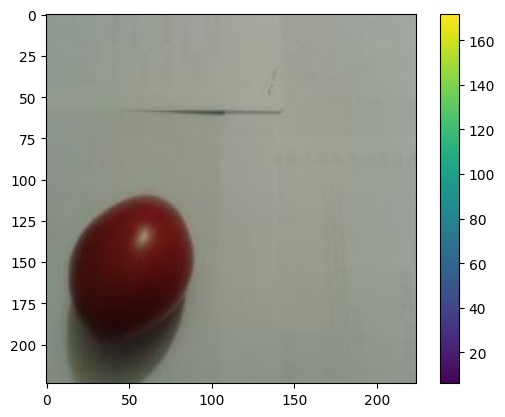

In [12]:
index = 0
np.set_printoptions(linewidth=320)

print(f'LABEL: {Y_train[index]}')
print(f'\nIMAGE PIXEL ARRAY: \n\n{X_train[index]}\n\n')

plt.imshow(X_train[index])
plt.colorbar()
plt.show()

In [16]:
X_train = X_train/255.0
X_test = X_test/255.0
X_val = X_val/255.0

In [20]:
print(X_train[0].shape)

(224, 224, 3)


In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (224, 224, 3)),

    tf.keras.layers.Conv2D(16, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation = 'relu'),
    tf.keras.layers.Dense(1, activation = 'sigmoid')
])

In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,785,985 (182.29 MB)

 Trainable params: 47,785,985 (182.29 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(
        train_iterator,
        validation_data=val_iterator, 
        epochs = 15, 
        batch_size = 32)

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 423ms/step - accuracy: 0.6167 - loss: 0.6838 - val_accuracy: 0.8333 - val_loss: 0.4493
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 391ms/step - accuracy: 0.7771 - loss: 0.4823 - val_accuracy: 0.8333 - val_loss: 0.3849
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 392ms/step - accuracy: 0.8042 - loss: 0.4376 - val_accuracy: 0.8750 - val_loss: 0.3469
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 384ms/step - accuracy: 0.8052 - loss: 0.4205 - val_accuracy: 0.8917 - val_loss: 0.3371
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 380ms/step - accuracy: 0.8396 - loss: 0.3914 - val_accuracy: 0.8000 - val_loss: 0.4165
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 383ms/step - accuracy: 0.8490 - loss: 0.3866 - val_accuracy: 0.8750 - val_loss: 0.3566
Epoch 7/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 385ms/step - accuracy: 0.8625 - loss: 0.3660 - val_accuracy: 0.9000 - val_loss: 0.3223
Epoch 8/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 381ms/step - accuracy: 0.8562 - loss: 0.3643 - val_accu

### Visualization of results

<Figure size 640x480 with 0 Axes>

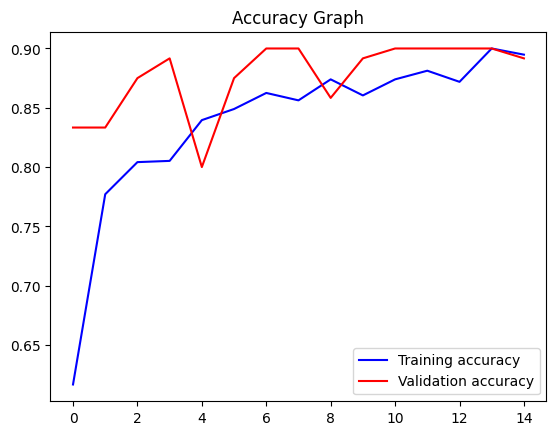

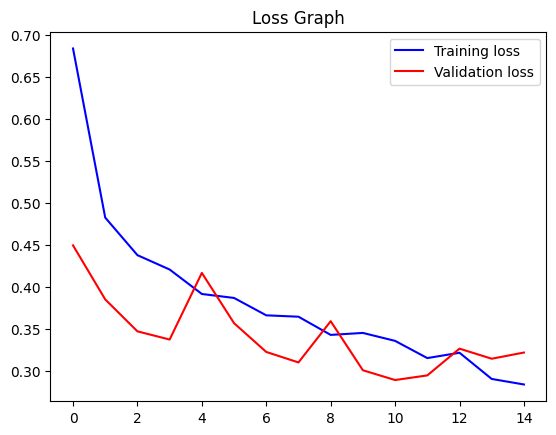

<Figure size 640x480 with 0 Axes>

In [34]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label = 'Training accuracy')
plt.plot(epochs, val_acc, 'r', label = 'Validation accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(val_loss))

plt.plot(epochs, loss, 'b', label = 'Training loss')
plt.plot(epochs, val_loss, 'r', label = 'Validation loss')
plt.title('Loss Graph')
plt.legend()
plt.figure()

In [35]:
model.save("tomato_health.keras")